# Binary Classification

In [1]:
import numpy as np  # for array operations
import matplotlib.pyplot as plt  # plotting

from keras.datasets import imdb  # imdb: Internet Movie Database
from keras import models, layers, optimizers, losses, metrics, regularizers
from keras.callbacks import History

Load the dataset

In [2]:
(train_data, train_labels),
  (test_data, test_labels) = imdb.load_data(num_words = 10000);

In [3]:
print(f"Train\n\tdata:   {train_data.shape}")
print(f"\tlabels: {train_labels.shape}")
print(f"Test\n\tdata:   {test_data.shape}")
print(f"\tlabels: {test_labels.shape}")

Train
	data:   (25000,)
	labels: (25000,)
Test
	data:   (25000,)
	labels: (25000,)


In [4]:
# word_index is a dictionary mapping words to an integer index
word_index = imdb.get_word_index()

# We reverse it, mapping integer indices to words
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

# We decode the review; note that our indices were offset by 3
# because 0, 1 and 2 are reserved indices for "padding", "start of sequence", and "unknown".
# 0: padding
# 1: start of sequence
# 2: unknown

# get i - 3, if not found, return '?'
# get i - 3 because 0, 1, 2 are reserved indices
# return '?' if not found, so it means that the word is not in the dictionary
decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in train_data[0]])
print(f"Decoded review:\n\t{decoded_review}")


Decoded review:
	? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have d

Now vectorize the data

In [5]:
def vectorize_sequences(sequences, dimension: int = 10000) -> np.ndarray:
    """
    One-hot encoding \n
    For each sequence, we create a 10,000-dimensional vector.
    All zeros except for indices corresponding to the words that the sequence contains.

    ### Args:
    - sequences: list of sequences
    - dimension 'int': dimension of the one-hot encoding
    
    ### Returns:
    - results: one-hot encoded sequences
    """
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))

    for i, sequence in enumerate(sequences):
        # Set specific indices of results[i] to 1s
        results[i, sequence] = 1.  # sequence is a list of indices

    return np.array(results)


Vectorize the data to feed it to the neural network.\
This means that we will convert the data into a vector of numbers, where each
number represents a word in the data.

```mermaid
graph TD
data[(data)] --> vec{{vectorize<br/>data}}
vec --> x_train
vec --> x_test
```

In [6]:
# X - data
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)
print(f"Train data:   {x_train.shape}")
print(f"Test data:    {x_test.shape}")

# Y - labels
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')
print(f"Train labels: {y_train.shape}")
print(f"Test labels:  {y_test.shape}")

Train data:   (25000, 10000)
Test data:    (25000, 10000)
Train labels: (25000,)
Test labels:  (25000,)


After vectorizing the data, we need to **split the data into training and
testing sets**. The training set is used to train the model, and the testing set
is used to evaluate the model.

In [7]:
# The validation set will be 10,000 samples from the original training data
x_val = x_train[:10000]  # first 10000 vectorized reviews (data)
y_val = y_train[:10000]  # first 10000 vectorized labels

# The training set will be the remaining 15,000 samples
partial_x_train = x_train[10000:]  # rest of the vectorized reviews (data)
partial_y_train = y_train[10000:]  # rest of the vectorized labels

### Create the model

In [8]:
model: models.Sequential = models.Sequential()

# Input - Layer
model.add(layers.Dense(16, activation="relu", input_shape=(10000,)))  # 10000 - dimension of the one-hot encoding
# 16 neurons in the first layer

# Hidden - Layers
model.add(layers.Dense(16, activation="relu"))
model.add(layers.Dense(16, activation="relu"))

# Output- Layer
model.add(layers.Dense(1, activation="sigmoid"))

In [9]:
model.summary()  # prints a summary of the model

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                160016    
                                                                 
 dense_1 (Dense)             (None, 16)                272       
                                                                 
 dense_2 (Dense)             (None, 16)                272       
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 160,577
Trainable params: 160,577
Non-trainable params: 0
_________________________________________________________________


### Compile the model

In [10]:
model.compile(
  optimizer = optimizers.RMSprop(learning_rate = 0.001),
  loss = losses.binary_crossentropy,
  metrics = [metrics.binary_accuracy],
);

### Train the model

In [11]:
# history var is used to plot the loss and accuracy of the model over the training and validation data during training
history: History = model.fit(
    partial_x_train,  # x: training data
    partial_y_train,  # y: target data (labels)
    epochs=12,  # An epoch is an iteration over the entire x and y data provided.
    batch_size=512,  # Number of samples per gradient update.
    # batch_size = 512 means that the model will take 512 samples from x_train and y_train and train itself 1 time
    # then it will take another 512 samples and train 1 time again etc. until it has used all samples (x_train, y_train)
    validation_data=(x_val, y_val)  # on which to evaluate the loss and any model metrics at the end of each epoch.
)

Epoch 1/12
30/30 [==============================] - 1s 16ms/step - loss: 0.5335 - binary_accuracy: 0.7779 - val_loss: 0.4223 - val_binary_accuracy: 0.8347
Epoch 2/12
30/30 [==============================] - 0s 10ms/step - loss: 0.2994 - binary_accuracy: 0.9017 - val_loss: 0.2975 - val_binary_accuracy: 0.8865
Epoch 3/12
30/30 [==============================] - 0s 10ms/step - loss: 0.2088 - binary_accuracy: 0.9319 - val_loss: 0.3086 - val_binary_accuracy: 0.8752
Epoch 4/12
30/30 [==============================] - 0s 10ms/step - loss: 0.1609 - binary_accuracy: 0.9482 - val_loss: 0.3345 - val_binary_accuracy: 0.8692
Epoch 5/12
30/30 [==============================] - 0s 10ms/step - loss: 0.1321 - binary_accuracy: 0.9586 - val_loss: 0.3693 - val_binary_accuracy: 0.8598
Epoch 6/12
30/30 [==============================] - 0s 10ms/step - loss: 0.1021 - binary_accuracy: 0.9698 - val_loss: 0.3380 - val_binary_accuracy: 0.8780
Epoch 7/12
30/30 [==============================] - 0s 9ms/step - loss

In [12]:
def plot_model_loss(history: History, model_name: str) -> None:
    """
    Plot the training and validation loss

    ### Args:
    - history: history of the model
    - epochs: number of epochs
    """
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)  # number of epochs

    # print historical data
    print(history.history.keys())

    # plot the training and validation loss
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.plot(epochs, loss, 'o', label='Training loss')  # bo: blue dot
    plt.plot(epochs, val_loss, '--', label='Validation loss')  # b: blue line
    plt.title(f'{model_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

As we can see, from the epoch 3 **the validation loss starts to increase**, this
means that the model **is starting to
[overfit](https://en.wikipedia.org/wiki/Overfitting) the data**.

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])


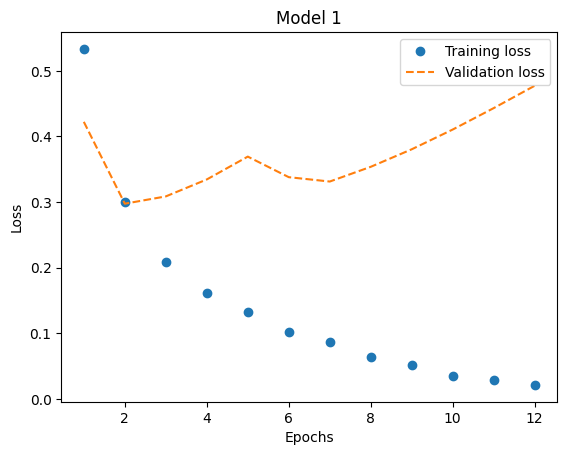

In [13]:
plot_model_loss(history, "Model 1");

### Evaluate the model

In [14]:
model.evaluate(x_test, y_test)  # returns the loss value & metrics values for the model in test mode

782/782 [==============================] - 1s 764us/step - loss: 0.5359 - binary_accuracy: 0.8606


[0.5358879566192627, 0.8605999946594238]

### [Reduce Overfitting](./../04_regularization_dropout.ipynb)

In [15]:
# use some techniques to reduce overfitting

#### Smaller Model

In [16]:
# create the same model as above 
small_model: models.Sequential = models.Sequential()

small_model.add(layers.Dense(4, activation="relu", input_shape=(10000,)))
small_model.add(layers.Dense(4, activation="relu"))
small_model.add(layers.Dense(1, activation="sigmoid"))

small_model.compile(
    optimizer=optimizers.RMSprop(learning_rate=0.001),
    loss=losses.binary_crossentropy,
    metrics=[metrics.binary_accuracy]
)

small_model_history: History = small_model.fit(
    partial_x_train,
    partial_y_train,
    epochs=12,
    batch_size=512,
    validation_data=(x_val, y_val)
)

Epoch 1/12
30/30 [==============================] - 1s 15ms/step - loss: 0.6326 - binary_accuracy: 0.6884 - val_loss: 0.5772 - val_binary_accuracy: 0.8030
Epoch 2/12
30/30 [==============================] - 0s 9ms/step - loss: 0.5270 - binary_accuracy: 0.8382 - val_loss: 0.5039 - val_binary_accuracy: 0.8423
Epoch 3/12
30/30 [==============================] - 0s 9ms/step - loss: 0.4452 - binary_accuracy: 0.8861 - val_loss: 0.4328 - val_binary_accuracy: 0.8684
Epoch 4/12
30/30 [==============================] - 0s 9ms/step - loss: 0.3657 - binary_accuracy: 0.9080 - val_loss: 0.3727 - val_binary_accuracy: 0.8820
Epoch 5/12
30/30 [==============================] - 0s 9ms/step - loss: 0.3002 - binary_accuracy: 0.9253 - val_loss: 0.3352 - val_binary_accuracy: 0.8823
Epoch 6/12
30/30 [==============================] - 0s 9ms/step - loss: 0.2521 - binary_accuracy: 0.9350 - val_loss: 0.3062 - val_binary_accuracy: 0.8872
Epoch 7/12
30/30 [==============================] - 0s 9ms/step - loss: 0.2

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])


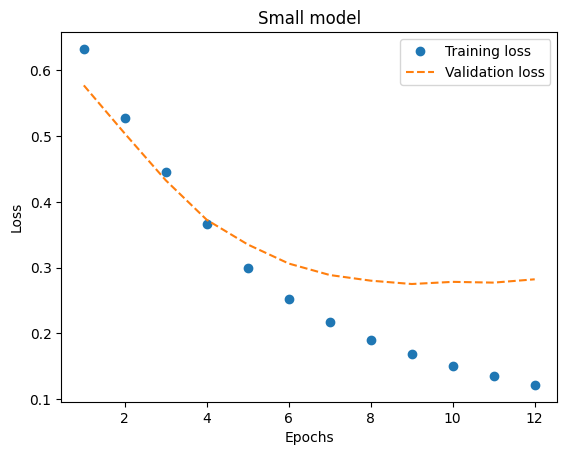

In [17]:
plot_model_loss(small_model_history, "Small model");

#### Regularization

In [18]:
reg_param: float = 0.001;

regularized_model: models.Sequential = models.Sequential();

regularized_model.add(
  layers.Dense(
    16,
    kernel_regularizer = regularizers.l2(reg_param),
    activation = "relu",
    input_shape = 10000,
  ),
);
regularized_model.add(
  layers.Dense(
    16,
    kernel_regularizer = regularizers.l2(reg_param),
    activation = "relu",
  ),
);
regularized_model.add(layers.Dense(1, activation = "sigmoid"));

regularized_model.compile(
  optimizer = optimizers.RMSprop(learning_rate = 0.001),
  loss = losses.binary_crossentropy,
  metrics = [metrics.binary_accuracy],
);

regularized_model_history: History = regularized_model.fit(
  partial_x_train,
  partial_y_train,
  epochs = 12,
  batch_size = 512,
  validation_data = (x_val, y_val),
);

Epoch 1/12
30/30 [==============================] - 1s 17ms/step - loss: 0.5812 - binary_accuracy: 0.7770 - val_loss: 0.4476 - val_binary_accuracy: 0.8649
Epoch 2/12
30/30 [==============================] - 0s 10ms/step - loss: 0.3709 - binary_accuracy: 0.8982 - val_loss: 0.3603 - val_binary_accuracy: 0.8875
Epoch 3/12
30/30 [==============================] - 0s 10ms/step - loss: 0.2974 - binary_accuracy: 0.9161 - val_loss: 0.3347 - val_binary_accuracy: 0.8896
Epoch 4/12
30/30 [==============================] - 0s 10ms/step - loss: 0.2583 - binary_accuracy: 0.9331 - val_loss: 0.3418 - val_binary_accuracy: 0.8837
Epoch 5/12
30/30 [==============================] - 0s 10ms/step - loss: 0.2360 - binary_accuracy: 0.9389 - val_loss: 0.3303 - val_binary_accuracy: 0.8883
Epoch 6/12
30/30 [==============================] - 0s 10ms/step - loss: 0.2187 - binary_accuracy: 0.9463 - val_loss: 0.3358 - val_binary_accuracy: 0.8857
Epoch 7/12
30/30 [==============================] - 0s 10ms/step - los

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])


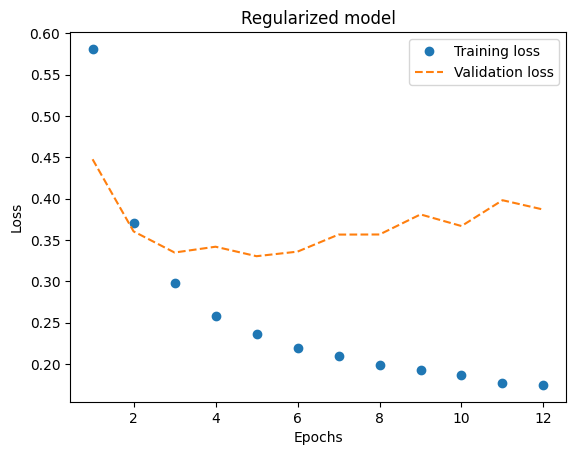

In [19]:
plot_model_loss(regularized_model_history, "Regularized model");

#### Dropout

In [20]:
dropout_model: models.Sequential = models.Sequential()

dropout_model.add(layers.Dense(16, activation="relu", input_shape=(10000,)))
# model.add(layers.Dropout(
    # rate: float = 0.5,  # [0..1] Is the fraction of the input units to drop.
    # noise_shape: Optional[Tuple[int, ...]] = None,  # 1D tensor with shape [batch_size] if noise_shape is None.
    # seed: Optional[int] = None,  # A Python integer to use as random seed.
dropout_model.add(layers.Dropout(0.5))
dropout_model.add(layers.Dense(16, activation="relu"))
dropout_model.add(layers.Dropout(0.5))
dropout_model.add(layers.Dense(1, activation="sigmoid"))

dropout_model.compile(
    optimizer=optimizers.RMSprop(learning_rate=0.001),
    loss=losses.binary_crossentropy,
    metrics=[metrics.binary_accuracy]
)

dropout_model_history: History = dropout_model.fit(
    partial_x_train,
    partial_y_train,
    epochs=12,
    batch_size=512,
    validation_data=(x_val, y_val)
)

Epoch 1/12
30/30 [==============================] - 1s 17ms/step - loss: 0.6498 - binary_accuracy: 0.6188 - val_loss: 0.5589 - val_binary_accuracy: 0.7839
Epoch 2/12
30/30 [==============================] - 0s 10ms/step - loss: 0.5404 - binary_accuracy: 0.7487 - val_loss: 0.4408 - val_binary_accuracy: 0.8679
Epoch 3/12
30/30 [==============================] - 0s 10ms/step - loss: 0.4533 - binary_accuracy: 0.8097 - val_loss: 0.3719 - val_binary_accuracy: 0.8784
Epoch 4/12
30/30 [==============================] - 0s 10ms/step - loss: 0.3842 - binary_accuracy: 0.8515 - val_loss: 0.3183 - val_binary_accuracy: 0.8845
Epoch 5/12
30/30 [==============================] - 0s 10ms/step - loss: 0.3302 - binary_accuracy: 0.8740 - val_loss: 0.2948 - val_binary_accuracy: 0.8879
Epoch 6/12
30/30 [==============================] - 0s 10ms/step - loss: 0.2877 - binary_accuracy: 0.8970 - val_loss: 0.2833 - val_binary_accuracy: 0.8839
Epoch 7/12
30/30 [==============================] - 0s 10ms/step - los

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])


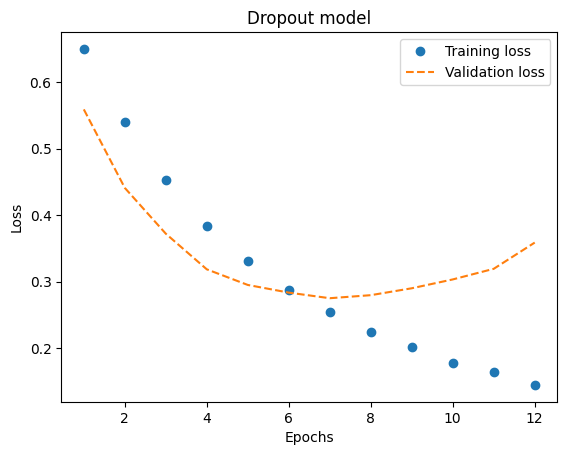

In [21]:
plot_model_loss(dropout_model_history, "Dropout model");

### Models Comparison

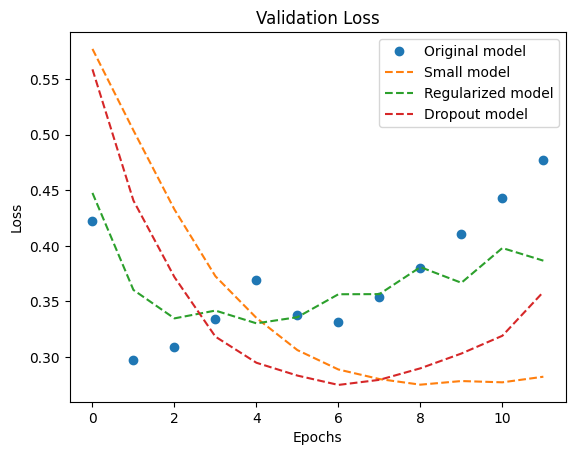

In [22]:
# plot the verification loss of the models
plt.plot(history.history['val_loss'], 'o', label='Original model')
plt.plot(small_model_history.history['val_loss'], '--', label='Small model')
plt.plot(regularized_model_history.history['val_loss'], '--', label='Regularized model')
plt.plot(dropout_model_history.history['val_loss'], '--', label='Dropout model')
plt.title('Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

As we can see, the original model presents the dropout since the epoch 2, so
it's not really a good model to iterate on.

Meanwhile, the **dropout model** presents the dropout since the epoch 6 and the
overfitting starts to increases really slowly, so **it's a good model to iterate
on**.